<a href="https://colab.research.google.com/github/MNIKIEMA/differentiable-wonderland-lab-sessions/blob/main/Lab_ViT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Guided lab session (PyTorch)

### Topic: Building a Vision Transformer

The lab implements a [Vision Transformer model](https://arxiv.org/abs/2010.11929) for image classification from scratch. This is mostly a didactical exercise, as the performances when trained on small-scale datasets are not very good.

In [1]:
# We use jaxtyping to annotate shapes
# https://docs.kidger.site/jaxtyping/api/array/
%pip install jaxtyping --quiet
from jaxtyping import Array, Float
from typing import Tuple

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 kB 6.8 MB/s eta 0:00:00


### Section 1: Loading a dataset

In [2]:
# Before running this cell, ensure you have a GPU selected (if available)
# from Runtime > Change runtime type.
%pip install pytorch_lightning torchmetrics --quiet
%pip install einops --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 61.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 70.4 MB/s eta 0:00:00


In [3]:
import torch
import torchvision
from torchvision.transforms import v2 as T
import matplotlib.pyplot as plt

In [4]:
import pytorch_lightning as pylight
from torchmetrics.classification import MulticlassAccuracy

In [4]:
# The size of the images we will use to train the model
IMG_SIZE = 256

In [5]:
# This specific dataset has three levels of granularity for the classes:
# https://pytorch.org/vision/main/generated/torchvision.datasets.FGVCAircraft.html
ANNOTATION_LEVEL = 'manufacturer' # Can be manufacturer, family, variant
NUM_CLASSES = {'manufacturer': 30, 'family': 70, 'variant': 100}[ANNOTATION_LEVEL]

In [6]:
transform_test = T.Compose([
        T.Resize((IMG_SIZE, IMG_SIZE)),
        T.ToImage(), # in v2, ToImage is used to convert into Tensor
        T.ToDtype(torch.float32, scale=True),
        T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

> **TODO**: after reading the documentation of `transforms`, (https://pytorch.org/vision/stable/transforms.html), add at least one data augmentation step in the previous series of transformations.

In [7]:
transform_train = T.Compose([
    T.RandomResizedCrop(size=(IMG_SIZE, IMG_SIZE), antialias=True),
    T.RandomHorizontalFlip(p=0.5),
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True),
])

In [8]:
planes_train = torchvision.datasets.FGVCAircraft('planes',
                                       transform=transform_train,
                                       split='trainval',
                                       annotation_level=ANNOTATION_LEVEL,
                                       download=True)

100%|██████████| 2.75G/2.75G [02:16<00:00, 20.1MB/s] 


In [9]:
planes_test = torchvision.datasets.FGVCAircraft('planes',
                                       transform=transform_test,
                                       split='test',
                                       annotation_level=ANNOTATION_LEVEL,
                                       download=True)

In [10]:
print(len(planes_train))
print(len(planes_test))

6667
3333


In [11]:
loader_train = torch.utils.data.DataLoader(planes_train, batch_size=16, shuffle=True, num_workers=2, pin_memory=True)
loader_test = torch.utils.data.DataLoader(planes_test, batch_size=16, shuffle=False, num_workers=2, pin_memory=True)

In [12]:
for xb, yb in loader_train:
  break

In [13]:
print(xb.shape)
print(yb.shape)

torch.Size([16, 3, 256, 256])
torch.Size([16])


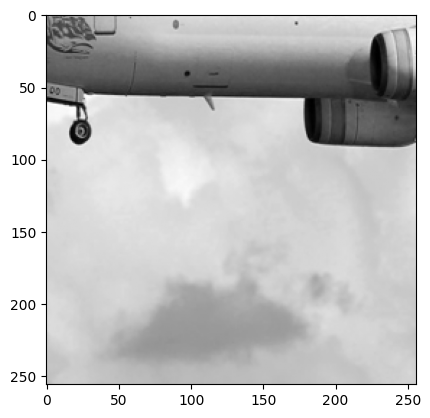

In [14]:
plt.imshow(xb[0, 0], cmap='gray')

### Section 2: Image tokenization

In [15]:
from torch import nn
import numpy as np
from einops.layers.torch import Rearrange
from einops import repeat
import math

There are many ways to decompose an image into patches. The simplest one (in my opinion) is `einops`, a library that simplifies the manipulation of high-dimensional matrices with many dimensions.

> **TODO**: after reading the Einops tutorial (https://einops.rocks/1-einops-basics/) write a function that takes a tensor of shape (batch_size, channels, height, width) and "patchifies" the image, returning a tensor of shape (batch_size, num_patches, patch_size, patch_size, channels).

In [16]:
PATCH_SIZE = 16
num_patches = (IMG_SIZE // PATCH_SIZE)**2

In [17]:
def patchify(x: Float[Array, "b c h w"], patch_size: int) -> Float[Array, "b num_patches patch_size patch_size c"]:
  # TODO: write the function
  patch_layer = Rearrange(
        'b c (h p1) (w p2) -> b (h w) p1 p2 c',
        p1=patch_size,
        p2=patch_size
    )
  return patch_layer(x)

In [18]:
xb_patches = patchify(xb, patch_size=PATCH_SIZE)

In [19]:
xb_patches.shape

torch.Size([16, 256, 16, 16, 3])

- We 256 image with dimension $16\times16\times3$

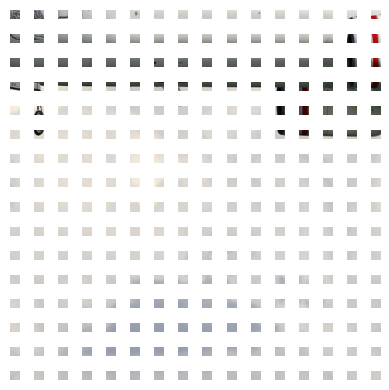

In [20]:
# Note: IMG_SIZE must be divisible by PATCH_SIZE
grid_size = int(math.sqrt(num_patches))

# Create figure with subplots
fig, axs = plt.subplots(grid_size, grid_size, figsize=(4, 4))
axs = axs.flatten()

for i in range(num_patches):
        # patch shape: (C, patch_size, patch_size)
        patch = xb_patches[0, i]

        # Display the patch
        axs[i].imshow(patch)
        axs[i].axis('off')

plt.tight_layout()
plt.show()

> **TODO**: Based on the previous function, write a layer that performs the tokenization step of the ViT. The output should be of shape (batch_size, num_patches, embedding_dim), where each patch is linearly projected to the corresponding embedding size.

In [21]:
EMBEDDING_DIM = 64

In [22]:
class Patchifier(nn.Module):
    def __init__(self, im_shape, patch_size=16, embedding_dim=128):
      super().__init__()
      self.n_patches = (im_shape // patch_size)**2
      self.flattened_patch_dim = patch_size * patch_size * 3 # c=3 for RGB images

      # TODO: add all required functions and layers
      self.patch_layer = Rearrange(
        'b c (h p1) (w p2) -> b (h w) p1 p2 c',
        p1=patch_size,
        p2=patch_size
        )
      self.embed_layer =  nn.Linear(self.flattened_patch_dim, embedding_dim)

    def forward(self, x: Float[Array, "b c h w"]) -> Float[Array, "b num_patches embedding_dim"]:
      # TODO: Extract the patches and perform the linear projection
      patches: Float[Array, "b num_patches patch_size patch_size c"] = self.patch_layer(x)
      flattened_patches: Float[Array, "b num_patches flattened_patch_dim"] = patches.flatten(2)
      return self.embed_layer(flattened_patches)

In [23]:
xb_tokenized = Patchifier(IMG_SIZE, embedding_dim=EMBEDDING_DIM)(xb)

In [24]:
# Should be (16, 256, 64) if you have not changed the hyper-parameters' setup.
print(xb_tokenized.shape)

torch.Size([16, 256, 64])


> **TODO**: write a layer that first performs the tokenization, and then adds (trainable) positional embeddings and the class token. The output shape should now be (batch_size, num_patches + 1, embedding_dim).

In [25]:
class ImageTokenizer(nn.Module):
    def __init__(self, im_shape, patch_size=16, embedding_dim=128):
      super().__init__()
      self.patchifier = Patchifier(im_shape, patch_size, embedding_dim)
      self.class_token = nn.Parameter(torch.randn(1, 1, embedding_dim))

      num_patches = self.patchifier.n_patches
      self.positional_embeddings = nn.Parameter(torch.randn(1, num_patches + 1, embedding_dim))

    def forward(self, x: Float[Array, "b c h w"]) -> Float[Array, "b patches embedding_dim"]:
      patch_embeddings = self.patchifier(x)

      batch_size = patch_embeddings.shape[0]
      expanded_class_token = repeat(self.class_token, '1 1 d -> b 1 d', b=batch_size)

      tokens = torch.cat((expanded_class_token, patch_embeddings), dim=1)

      # Add positional embeddings
      return tokens + self.positional_embeddings

In [26]:
xb_tokenized = ImageTokenizer(IMG_SIZE, embedding_dim=EMBEDDING_DIM)(xb)

In [27]:
# Should be (16, 197, 128)
print(xb_tokenized.shape)

torch.Size([16, 257, 64])


### Section 3: Implementing the attention layer

> **TODO**: implement a self-attention layer (for simplicity we focus on a single-head scenario), which implements $\mathbf{H} = \text{softmax}(\mathbf{Q}\mathbf{K}^\top)\mathbf{V}$ (ignoring the normalization factor), where the query, key, and matrices are linear projections of the input vectors.

In [28]:
class SelfAttention(nn.Module):

    def __init__(self, embedding_dim=128):
        super().__init__()
        self.embedding_dim = embedding_dim

        # Initialize linear layers for Q, K, V projections
        self.W_k = nn.Linear(embedding_dim, embedding_dim)
        self.W_q = nn.Linear(embedding_dim, embedding_dim)
        self.W_v = nn.Linear(embedding_dim, embedding_dim)

    def forward(self, x: Float[Array, "b patches embedding_dim"]) -> \
                                Tuple[Float[Array, "b patches embedding_dim"], Float[Array, "b patches patches"]]:
        # TODO: write the forward pass.
        # You should return both H and the attention maps.
        # Project x to Q, K, V
        Q = self.W_q(x)
        K = self.W_k(x)
        V = self.W_v(x)

        # Calculate attention scores
        score = torch.matmul(Q, K.transpose(-2, -1))
        attention_maps = torch.nn.functional.softmax(score, dim=-1)

        # Multiply attention maps with V
        output = torch.matmul(attention_maps, V)

        return output, attention_maps

In [29]:
out, attn = SelfAttention(EMBEDDING_DIM)(xb_tokenized)

In [30]:
print(attn.shape)

torch.Size([16, 257, 257])


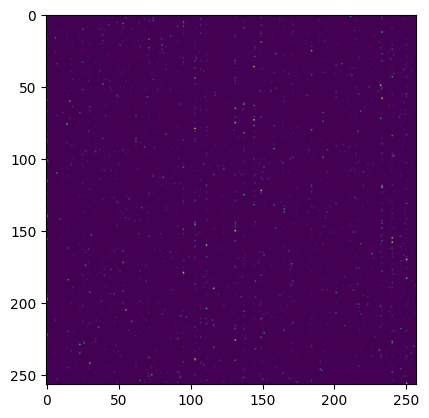

In [31]:
plt.imshow(attn[0].detach().numpy(), cmap='viridis')

> **TODO**: implement the "transformer block", which is composed of MHA, MLPs, layer normalization, and residual connection blocks:

$$ \mathbf{X} = \mathbf{X} + \text{MHA}(\text{LN}(\mathbf{X})) \\ \mathbf{X} = \mathbf{X} + \text{MLP}(\text{LN}(\mathbf{X})) $$

In [ ]:
class TransformerBlock(nn.Module):

    def __init__(self, embedding_dim=128, num_heads=8):
        super().__init__()
        self.embedding_dim = embedding_dim
        self.num_heads = num_heads
        self.head_dim = embedding_dim // num_heads
        assert self.head_dim * num_heads == embedding_dim, "embedding_dim must be divisible by num_heads"

        # TODO: add all necessary layers and functions.
        self.qkv_proj = nn.Linear(embedding_dim, embedding_dim * 3, bias=False)
        self.out_proj = nn.Linear(embedding_dim, embedding_dim)

        self.norm1 = nn.LayerNorm(embedding_dim)

        self.mlp = nn.Sequential(
            nn.Linear(embedding_dim, 4 * embedding_dim),
            nn.GELU(),
            nn.Linear(4 * embedding_dim, embedding_dim)
        )
        self.norm2 = nn.LayerNorm(embedding_dim)

    def forward(self, x: Float[Array, "b patches embedding_dim"]) -> Float[Array, "b patches embedding_dim"]:
        # TODO: write the forward pass.
        # Multi-Head Attention block
        residual = x
        x_norm = self.norm1(x)

        b, n, d = x_norm.shape

        qkv = self.qkv_proj(x_norm).reshape(b, n, 3, self.num_heads, self.head_dim)
        # Permute to get (3, batch_size, num_heads, num_patches, head_dim)
        q, k, v = qkv.permute(2, 0, 3, 1, 4)

        # Scaled Dot-Product Attention
        # Attention scores: (b, num_heads, n, head_dim) @ (b, num_heads, head_dim, n) -> (b, num_heads, n, n)
        attn_scores: Float[Array, "b, num_heads, n, n"] = q @ k.transpose(-2, -1)
        attn_weights: Float[Array, "b, num_heads, n, n"] = torch.nn.functional.softmax(attn_scores, dim=-1)

        # (b, num_heads, n, n) @ (b, num_heads, n, head_dim) -> (b, num_heads, n, head_dim)
        attn_output: Float[Array, "b, num_heads, n, head_dim"] = attn_weights @ v

        # Concatenate heads and apply final linear projection
        # (b, num_heads, n, head_dim) -> (b, n, num_heads, head_dim) -> (b, n, embedding_dim)
        attn_output: Float[Array, "b, n, embedding_dim"] = attn_output.transpose(1, 2).reshape(b, n, d)
        mha_output: Float[Array, "b patches embedding_dim"] = self.out_proj(attn_output)

        x = residual + mha_output

        x = x + self.mlp(self.norm2(x))
        return x

In [37]:
print(TransformerBlock(EMBEDDING_DIM)(xb_tokenized).shape)

torch.Size([16, 257, 64])


### Section 4: Building (and training) the final model

Note: vision transformers are highly inefficient when trained from scratch, which is why the results will underperform.

> **TODO**: write the complete model by assembling all the components, and see how it performs!

In [54]:
import torch.nn.functional as F
import pytorch_lightning as pylight
from torchmetrics.classification import MulticlassAccuracy

In [49]:
class VisionTransformer(nn.Module):
    def __init__(self, image_size, num_classes, embedding_dim=128, num_blocks=3, num_heads=8):
      super().__init__()
      # TODO: initialize all necessary layers and functions
      self.tokenizer_layer = ImageTokenizer(im_shape=image_size, embedding_dim=embedding_dim)
      self.trf_block = nn.Sequential(
    *[TransformerBlock(embedding_dim=embedding_dim, num_heads=num_heads) for _ in range(num_blocks)]
    )
      self.cls_layer = nn.Linear(embedding_dim, num_classes)

    def forward(self, x: Float[Array, "b channel h w"]) -> Float[Array, "b num_classes"]:
      # TODO: write the forward pass
      x = self.tokenizer_layer(x)
      x = self.trf_block(x)
      cls_token_output: Float[Array, "b embedding_dim"] = x[:, 0, :]
      return self.cls_layer(cls_token_output)

In [50]:
vit = VisionTransformer(IMG_SIZE, NUM_CLASSES, EMBEDDING_DIM)

In [51]:
print(vit(xb).shape)
print(vit(xb).argmax(-1))

torch.Size([16, 30])
tensor([29, 29, 29, 29, 29, 29, 29, 29, 29, 29, 29, 29, 29, 29, 29, 29])


In [55]:
class Wrapper(pylight.LightningModule):

  def __init__(self, model: nn.Module=None, num_classes=100):
    super().__init__()
    self.model = model
    self.acc = MulticlassAccuracy(num_classes)

  def forward(self, x):
    return self.model(x)

  def configure_optimizers(self):
    return torch.optim.AdamW(self.model.parameters())

  def step(self, batch, name='train', on_step=True, on_epoch=False):
    xb, yb = batch
    y_pred = self(xb)
    loss = F.cross_entropy(y_pred, yb)
    self.acc(y_pred, yb)
    self.log(f"{name}/loss", loss, on_step=on_step, on_epoch=on_epoch, prog_bar=True)
    self.log(f"{name}/acc", self.acc, on_step=on_step, on_epoch=on_epoch, prog_bar=True)
    return loss

  def training_step(self, batch, _):
    return self.step(batch, 'train', on_step=True, on_epoch=False)

  def validation_step(self, batch, _):
    return self.step(batch, 'val', on_step=False, on_epoch=True)

  def test_step(self, batch, _):
    return self.step(batch, 'test', on_step=True, on_epoch=False)

In [56]:
vit_wrapper = Wrapper(VisionTransformer(IMG_SIZE, NUM_CLASSES, embedding_dim=EMBEDDING_DIM, num_heads=4, num_blocks=4), num_classes=NUM_CLASSES)
# vit_wrapper = torch.compile(wrapper)

In [57]:
# As a comparison: a fine-tuned CNN!
class ResNet(nn.Module):
  def __init__(self, num_classes):
    super().__init__()
    self.transform = torchvision.models.ResNet18_Weights.IMAGENET1K_V1.transforms()
    self.cnn = torchvision.models.resnet18('IMAGENET1K_V1')
    for param in self.cnn.parameters():
      param.requires_grad = False
    self.cnn.fc = torch.nn.Linear(in_features=512, out_features=num_classes)

  def forward(self, x):
    x = self.transform(x)
    return self.cnn(x)

In [58]:
cnn = ResNet(NUM_CLASSES)
print(cnn(xb).shape)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:135: UserWarning: Using 'weights' as positional parameter(s) is deprecated since 0.13 and may be removed in the future. Please use keyword parameter(s) instead.
  warnings.warn(


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 192MB/s]


torch.Size([16, 30])


In [59]:
cnn_wrapper = Wrapper(ResNet(NUM_CLASSES), num_classes=NUM_CLASSES)

In [60]:
device = 'gpu' if torch.cuda.is_available() else 'cpu'
print(device)

gpu


In [61]:
# See https://lightning.ai/docs/pytorch/stable/advanced/training_tricks.html#accumulate-gradients for a few suggestions
trainer = pylight.Trainer(max_epochs=10, accelerator=device, devices=1,
                          accumulate_grad_batches=2)                                              # Accumulate gradients over batches
                          #callbacks=[pylight.callbacks.StochasticWeightAveraging(swa_lrs=1e-2)],  # Stochastic weight averaging
                          #precision='16-mixed')                                                           # Mixed precision

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


In [62]:
trainer.fit(vit_wrapper, loader_train, loader_test)

INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model │ VisionTransformer  │  266 K │ train │     0 │
│ 1 │ acc   │ MulticlassAccuracy │      0 │ train │     0 │
└───┴───────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 266 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 266 K                                                                                                
Total estimated model params size (MB): 1                                                                          
Modules in train mode: 44                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.


In [63]:
trainer.fit(cnn_wrapper, loader_train, loader_test)

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /content/lightning_logs/version_0/checkpoints exists and is not empty.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model │ ResNet             │ 11.2 M │ train │     0 │
│ 1 │ acc   │ MulticlassAccuracy │      0 │ train │     0 │
└───┴───────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 15.4 K                                                                                           
Non-trainable params: 11.2 M                                                                                       
Total params: 11.2 M                                                                                               
Total estimated model params size (MB): 44                                                                         
Modules in train mode: 71                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.


In [64]:
%reload_ext tensorboard
%tensorboard --logdir=lightning_logs/

<IPython.core.display.Javascript object>